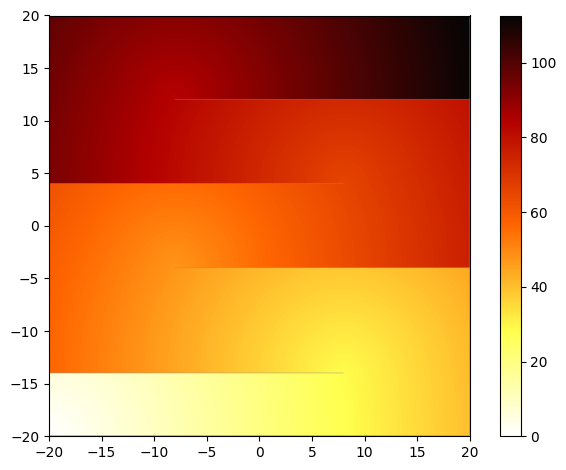

In [7]:
# ==============================================================================
# --------- VERSIONE FIM PARALLELIZZATA IN RAWKERNEL SU LABIRINTO 500X500 ------
# ==============================================================================

#------------------  LIBRERIE --------------------------------------------------

import cupy as cp
import numpy as np
import matplotlib.pyplot as plt

from scipy.interpolate import RegularGridInterpolator
from matplotlib.colors import LinearSegmentedColormap
from google.colab import drive


#------------------  DISCRETIZZAZIONE DEL DOMINIO ------------------------------

# dominio 500x500
"""
nx = 500
ny = 500
nRows = 500
nCols = 500
sidex = 5
sidey = 5
domain = [-sidex, sidex, -sidey, sidey]
x = np.linspace(domain[0], domain[1], nx)
y = np.linspace(domain[2], domain[3], ny)
dx = x[1] - x[0]
dy = y[1] - y[0]
[X, Y] = np.meshgrid(x, y)
eps = 1e-6
h = dx

ix0 = 5
iy0 = 5
"""

# dominio 1000x1000
"""
nx = 1000
ny = 1000
nRows = 1000
nCols = 1000
sidex = 10
sidey = 10
domain = [-sidex, sidex, -sidey, sidey]
x = np.linspace(domain[0], domain[1], nx)
y = np.linspace(domain[2], domain[3], ny)
dx = x[1] - x[0]
dy = y[1] - y[0]
[X, Y] = np.meshgrid(x, y)
eps = 1e-6
h = dx

ix0 = 5
iy0 = 5
"""

# dominio 2000x2000

nx = 2000
ny = 2000
nRows = 2000
nCols = 2000
sidex = 20
sidey = 20
domain = [-sidex, sidex, -sidey, sidey]
x = np.linspace(domain[0], domain[1], nx)
y = np.linspace(domain[2], domain[3], ny)
dx = x[1] - x[0]
dy = y[1] - y[0]
[X, Y] = np.meshgrid(x, y)
eps = 1e-6

ix0 = 5
iy0 = 5


#------------------  CAMPO DI VELOCITA' (LABIRINTO) ----------------------------

F = np.ones(X.shape, dtype=np.float32)

#dominio 500x500

"""
F[:, 1]   = np.inf   # parete sinistra
F[:, 498] = np.inf   # parete destra
F[1, :]   = np.inf   # parete sopra
F[498, :] = np.inf   # parete sotto

# primo muro orizzontale (riga 100, con apertura a sinistra)
F[99, :]       = np.inf
F[99, 349:498] = 1
# secondo muro orizzontale (riga 200, con apertura a destra)
F[199, :]      = np.inf
F[199, 1:150]  = 1

# terzo muro orizzontale (riga 300, con apertura a sinistra)
F[299, :]       = np.inf
F[299, 349:498] = 1

# quarto muro orizzontale (riga 400, con apertura a destra)
F[399, :]      = np.inf
F[399, 1:150]  = 1
"""


# dominio 1000x1000
"""

# pareti del bordo
F[:, 1]   = np.inf   # parete sinistra
F[:, 999] = np.inf   # parete destra
F[1, :]   = np.inf   # parete sopra
F[999, :] = np.inf   # parete sotto

# primo muro orizzontale (riga 100, con apertura a sinistra)
F[199, :]       = np.inf
F[199, 699:999] = 1   # apertura: colonne 350-498 in MATLAB → 349:498 in Python

# secondo muro orizzontale (riga 200, con apertura a destra)
F[399, :]      = np.inf
F[399, 1:299]  = 1   # apertura: colonne 2-150 in MATLAB → 1:150 in Python

# terzo muro orizzontale (riga 300, con apertura a sinistra)
F[599, :]       = np.inf
F[599, 699:999] = 1

# quarto muro orizzontale (riga 400, con apertura a destra)
F[799, :]      = np.inf
F[799, 1:299]  = 1
"""

# dominio 2000x2000

# pareti del bordo
F[:, 1]   = np.inf   # parete sinistra
F[:, 1999] = np.inf   # parete destra
F[1, :]   = np.inf   # parete sopra
F[1999, :] = np.inf   # parete sotto

# primo muro orizzontale (riga 100, con apertura a sinistra)
F[299, :]       = np.inf
F[299, 1399:1999] = 1   # apertura: colonne 350-498 in MATLAB → 349:498 in Python

# secondo muro orizzontale (riga 200, con apertura a destra)
F[799, :]      = np.inf
F[799, 1:599]  = 1   # apertura: colonne 2-150 in MATLAB → 1:150 in Python

# terzo muro orizzontale (riga 300, con apertura a sinistra)
F[1199, :]       = np.inf
F[1199, 1399:1999] = 1

# quarto muro orizzontale (riga 400, con apertura a destra)
F[1599, :]      = np.inf
F[1599, 1:599]  = 1



# ==============================================================================
# CALCOLO ICONALE PARALLELIZZATO IN RAWKERNEL
# ==============================================================================

#------------------  SORGENTE --------------------------------------------------

ix0, iy0 = 5, 5
T = np.full(X.shape, np.inf, dtype=np.float32)
T[iy0, ix0] = 0.0

active = np.zeros(T.shape, dtype=bool)
for dr, dc in [(0,-1),(0,1),(-1,0),(1,0)]:
    nr, nc = iy0 + dr, ix0 + dc
    if 0 <= nr < nRows and 0 <= nc < nCols:
        active[nr, nc] = True


#------------------  UPLOAD CPU -> GPU -----------------------------------------

T_gpu      = cp.array(T)
F_gpu      = cp.array(F)
active_gpu = cp.array(active)


#------------------ GODUNOV 1 --------------------------------------------------

godunov_kernel_code = r'''
extern "C" __global__
void godunov_update(
    const float* T,        // matrice T corrente (nRows x nCols)
    const float* F,        // campo velocità    (nRows x nCols)
    const int*   rows,     // indici riga  dei nodi attivi
    const int*   cols,     // indici colonna dei nodi attivi
    float*       T_new,    // valori aggiornati (output, stessa dim di rows)
    int          n_active, // numero di nodi attivi
    int          nRows,
    int          nCols,
    float        h
) {
    // indice globale del thread → indice nel vettore dei nodi attivi
    int i = blockIdx.x * blockDim.x + threadIdx.x;
    if (i >= n_active) return;

    int r = rows[i];
    int c = cols[i];

    // se il nodo stesso è un muro, non fare nulla
    if (isinf(F[r * nCols + c])) {
        T_new[i] = T[r * nCols + c];
        return;
    }

    // leggi i vicini (usa inf se fuori griglia o muro)
    float left  = (c - 1 >= 0)    ? T[r * nCols + (c-1)] : 1e30f;
    float right = (c + 1 < nCols) ? T[r * nCols + (c+1)] : 1e30f;
    float down  = (r - 1 >= 0)    ? T[(r-1) * nCols + c] : 1e30f;
    float up    = (r + 1 < nRows) ? T[(r+1) * nCols + c] : 1e30f;

    float Txmin = fminf(left, right);
    float Tymin = fminf(down, up);

    float a = fminf(Txmin, Tymin);
    float b = fmaxf(Txmin, Tymin);

    float f   = F[r * nCols + c];
    float rhs = h / f;

    float result;
    if ((b - a) < rhs) {
        float disc = 2.0f * rhs*rhs - (a - b)*(a - b);
        if (disc < 0.0f) disc = 0.0f;
        result = (a + b + sqrtf(disc)) / 2.0f;
    } else {
        result = a + rhs;
    }

    T_new[i] = result;
}
'''

godunov_ker = cp.RawKernel(godunov_kernel_code, 'godunov_update')


#------------------  AGGIORNAMENTO FIM  ----------------------------------------

def FIM(T, F, active):

    threads_per_block = 256

    while cp.any(active):

        row, col = cp.where(active)
        n_active = len(row)

        # prepara array di output per i valori aggiornati
        T_new = cp.empty(n_active, dtype=cp.float32)

        # calcolo griglia
        blocchi = (n_active + threads_per_block - 1) // threads_per_block

        # lancia il kernel
        godunov_ker(
            (blocchi,), (threads_per_block,),
            (T, F,
             row.astype(cp.int32), col.astype(cp.int32),
             T_new,
             cp.int32(n_active), cp.int32(nRows), cp.int32(nCols),
             cp.float32(h))
        )

        # aggiorna T con i nuovi valori
        p = T[row, col].copy()
        T[row, col] = T_new

        # check convergenza
        converged_cond = cp.abs(p - T_new) < eps
        conv_row = row[converged_cond]
        conv_col = col[converged_cond]
        active[conv_row, conv_col] = False

        # propagazione ai vicini (invariata)
        all_nb_row = cp.concatenate([conv_row-1, conv_row+1,
                                     conv_row,   conv_row  ])
        all_nb_col = cp.concatenate([conv_col,   conv_col,
                                     conv_col-1, conv_col+1])

        valid = ((all_nb_row >= 0) & (all_nb_row < nRows) &
                 (all_nb_col >= 0) & (all_nb_col < nCols))
        nb_row = all_nb_row[valid]
        nb_col = all_nb_col[valid]

        if nb_row.size == 0:
            continue

        not_wall = ~cp.isinf(F[nb_row, nb_col])
        nb_row = nb_row[not_wall]
        nb_col = nb_col[not_wall]

        if nb_row.size == 0:
            continue

        # per i vicini usi ancora il kernel
        n_nb = len(nb_row)
        T_nb_new = cp.empty(n_nb, dtype=cp.float32)
        blocchi_nb = (n_nb + threads_per_block - 1) // threads_per_block

        godunov_ker(
            (blocchi_nb,), (threads_per_block,),
            (T, F,
             nb_row.astype(cp.int32), nb_col.astype(cp.int32),
             T_nb_new,
             cp.int32(n_nb), cp.int32(nRows), cp.int32(nCols),
             cp.float32(h))
        )

        improve = T_nb_new < T[nb_row, nb_col]
        nb_row, nb_col = nb_row[improve], nb_col[improve]
        T_nb_new = T_nb_new[improve]

        T[nb_row, nb_col] = T_nb_new
        active[nb_row, nb_col] = True

    return T


#------------------  SOLVE AND UPLOAD GPU -> CPU -------------------------------

T_final_gpu = FIM(T_gpu, F_gpu, active_gpu)

# torna su CPU solo per il plot
T_final = cp.asnumpy(T_final_gpu)

#------------------  SALVATAGGIO IN DRIVE --------------------------------------

"""
drive.mount('/content/drive')

save_path = '/content/drive/MyDrive/Colab Notebooks/Risultati/'


np.savez(save_path + 'T_fim_gpu.npz', T_ref = T_final)
"""

#------------------  STAMPA DEI RISULTATI --------------------------------------

fig, ax = plt.subplots()
im = ax.imshow(T_final, extent=[x.min(), x.max(), y.min(), y.max()],
               origin='lower', aspect='equal')
plt.colorbar(im, ax=ax)

stops = np.array([
    [1.00, 1.00, 1.00],
    [1.00, 1.00, 0.30],
    [1.00, 0.40, 0.00],
    [0.70, 0.00, 0.00],
    [0.02, 0.02, 0.02],
])
cmap2 = LinearSegmentedColormap.from_list("custom", stops, N=256)
im.set_cmap(cmap2)
plt.tight_layout()
plt.show()

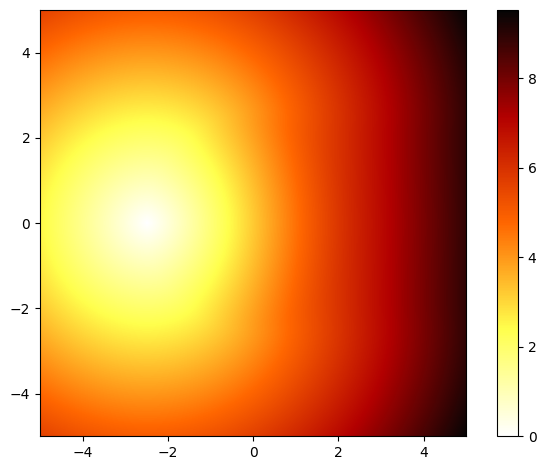

In [ ]:
# ==============================================================================
# --------- VERSIONE FIM PARALLELIZZATA IN RAWKERNEL SU LENTE LUNEBURG ---------
# ==============================================================================

#------------------  LIBRERIE --------------------------------------------------

import cupy as cp
import numpy as np
import matplotlib.pyplot as plt

from scipy.interpolate import RegularGridInterpolator
from matplotlib.colors import LinearSegmentedColormap
from google.colab import drive

#------------------  DISCRETIZZAZIONE DEL DOMINIO ------------------------------

nx, ny   = 500, 500
nRows, nCols = 500, 500
sidex, sidey = 5, 5
domain = [-sidex, sidex, -sidey, sidey]
x  = np.linspace(domain[0], domain[1], nx)
y  = np.linspace(domain[2], domain[3], ny)
dx = x[1] - x[0]
dy = y[1] - y[0]
X, Y = np.meshgrid(x, y)
eps = 1e-6
h = dx

#------------------  CAMPO DI VELOCITA' (LENTE DI LUNEBURG) --------------------
F_oncart = RegularGridInterpolator((X[0, :], Y[:, 0]), np.ones(X.shape).T,
                                    method='linear', bounds_error=False, fill_value=None)

# --- parametri della lente --
R_lens = 2.5        # raggio della lente di Luneburg
xc, yc = 0.0, 0.0   # centro della lente (nell'origine del dominio)
rho = np.sqrt((X - xc)**2 + (Y - yc)**2)
inside = rho < R_lens

n_luneburg = np.ones(X.shape)
n_luneburg[inside] = np.sqrt(2.0 - (rho[inside] / R_lens)**2)

F = np.ones(X.shape)
F = 1.0 / n_luneburg   # F è la VELOCITA', reciproca dell'indice di rifrazione
F[inside] = 1.0 / np.sqrt(2.0 - (rho[inside] / R_lens)**2)

wall_mask = np.isinf(F)


# ==============================================================================
# CALCOLO ICONALE PARALLELIZZATO IN RAWKERNEL
# ==============================================================================

#------------------  SORGENTE --------------------------------------------------

#punto iniziale (sorgente) — nel fuoco, cioè sul bordo della lente
ix0 = np.argmin(np.abs(x - (xc - R_lens)))   # colonna corrispondente a x = xc - R_lens
iy0 = np.argmin(np.abs(y - yc))              # riga corrispondente a y = yc

source_pt = (x[ix0], y[iy0])   # coordinate fisiche della sorgente (il fuoco della lente)

T = np.full(X.shape, np.inf)
T[iy0, ix0] = 0

active = np.zeros(T.shape, dtype=bool)
for dr, dc in [(0,-1),(0,1),(-1,0),(1,0)]:
    nr, nc = iy0 + dr, ix0 + dc
    if 0 <= nr < nRows and 0 <= nc < nCols:
        active[nr, nc] = True

#------------------  UPLOAD CPU -> GPU -----------------------------------------

F = F.astype(np.float32)
T = T.astype(np.float32)
T_gpu      = cp.array(T)
F_gpu      = cp.array(F)
active_gpu = cp.array(active)


#------------------ GODUNOV 1 --------------------------------------------------

godunov_kernel_code = r'''
extern "C" __global__
void godunov_update(
    const float* T,        // matrice T corrente (nRows x nCols)
    const float* F,        // campo velocità    (nRows x nCols)
    const int*   rows,     // indici riga  dei nodi attivi
    const int*   cols,     // indici colonna dei nodi attivi
    float*       T_new,    // valori aggiornati (output, stessa dim di rows)
    int          n_active, // numero di nodi attivi
    int          nRows,
    int          nCols,
    float        h
) {
    // indice globale del thread → indice nel vettore dei nodi attivi
    int i = blockIdx.x * blockDim.x + threadIdx.x;
    if (i >= n_active) return;

    int r = rows[i];
    int c = cols[i];

    // se il nodo stesso è un muro, non fare nulla
    if (isinf(F[r * nCols + c])) {
        T_new[i] = T[r * nCols + c];
        return;
    }

    // leggi i vicini (usa inf se fuori griglia o muro)
    float left  = (c - 1 >= 0)    ? T[r * nCols + (c-1)] : 1e30f;
    float right = (c + 1 < nCols) ? T[r * nCols + (c+1)] : 1e30f;
    float down  = (r - 1 >= 0)    ? T[(r-1) * nCols + c] : 1e30f;
    float up    = (r + 1 < nRows) ? T[(r+1) * nCols + c] : 1e30f;

    float Txmin = fminf(left, right);
    float Tymin = fminf(down, up);

    float a = fminf(Txmin, Tymin);
    float b = fmaxf(Txmin, Tymin);

    float f   = F[r * nCols + c];
    float rhs = h / f;

    float result;
    if ((b - a) < rhs) {
        float disc = 2.0f * rhs*rhs - (a - b)*(a - b);
        if (disc < 0.0f) disc = 0.0f;
        result = (a + b + sqrtf(disc)) / 2.0f;
    } else {
        result = a + rhs;
    }

    T_new[i] = result;
}
'''

godunov_ker = cp.RawKernel(godunov_kernel_code, 'godunov_update')


#------------------  AGGIORNAMENTO FIM  ----------------------------------------

def FIM(T, F, active):

    threads_per_block = 256

    while cp.any(active):

        row, col = cp.where(active)
        n_active = len(row)

        # prepara array di output per i valori aggiornati
        T_new = cp.empty(n_active, dtype=cp.float32)

        # calcolo griglia
        blocchi = (n_active + threads_per_block - 1) // threads_per_block

        # lancia il kernel
        godunov_ker(
            (blocchi,), (threads_per_block,),
            (T, F,
             row.astype(cp.int32), col.astype(cp.int32),
             T_new,
             cp.int32(n_active), cp.int32(nRows), cp.int32(nCols),
             cp.float32(h))
        )

        # aggiorna T con i nuovi valori
        p = T[row, col].copy()
        T[row, col] = T_new

        # check convergenza
        converged_cond = cp.abs(p - T_new) < eps
        conv_row = row[converged_cond]
        conv_col = col[converged_cond]
        active[conv_row, conv_col] = False

        # propagazione ai vicini (invariata)
        all_nb_row = cp.concatenate([conv_row-1, conv_row+1,
                                     conv_row,   conv_row  ])
        all_nb_col = cp.concatenate([conv_col,   conv_col,
                                     conv_col-1, conv_col+1])

        valid = ((all_nb_row >= 0) & (all_nb_row < nRows) &
                 (all_nb_col >= 0) & (all_nb_col < nCols))
        nb_row = all_nb_row[valid]
        nb_col = all_nb_col[valid]

        if nb_row.size == 0:
            continue

        not_wall = ~cp.isinf(F[nb_row, nb_col])
        nb_row = nb_row[not_wall]
        nb_col = nb_col[not_wall]

        if nb_row.size == 0:
            continue

        # per i vicini usi ancora il kernel
        n_nb = len(nb_row)
        T_nb_new = cp.empty(n_nb, dtype=cp.float32)
        blocchi_nb = (n_nb + threads_per_block - 1) // threads_per_block

        godunov_ker(
            (blocchi_nb,), (threads_per_block,),
            (T, F,
             nb_row.astype(cp.int32), nb_col.astype(cp.int32),
             T_nb_new,
             cp.int32(n_nb), cp.int32(nRows), cp.int32(nCols),
             cp.float32(h))
        )

        improve = T_nb_new < T[nb_row, nb_col]
        nb_row, nb_col = nb_row[improve], nb_col[improve]
        T_nb_new = T_nb_new[improve]

        T[nb_row, nb_col] = T_nb_new
        active[nb_row, nb_col] = True

    return T


#------------------  SOLVE AND UPLOAD GPU -> CPU -------------------------------

T_final_gpu = FIM(T_gpu, F_gpu, active_gpu)

# torna su CPU solo per il plot
T_final = cp.asnumpy(T_final_gpu)

#------------------  SALVATAGGIO IN DRIVE --------------------------------------

"""
drive.mount('/content/drive')

save_path = '/content/drive/MyDrive/Colab Notebooks/Risultati/'


np.savez(save_path + 'T_fim_gpu.npz', T_ref = T_final)
"""

#------------------  STAMPA DEI RISULTATI --------------------------------------

fig, ax = plt.subplots()
im = ax.imshow(T_final, extent=[x.min(), x.max(), y.min(), y.max()],
               origin='lower', aspect='equal')
plt.colorbar(im, ax=ax)

stops = np.array([
    [1.00, 1.00, 1.00],
    [1.00, 1.00, 0.30],
    [1.00, 0.40, 0.00],
    [0.70, 0.00, 0.00],
    [0.02, 0.02, 0.02],
])
cmap2 = LinearSegmentedColormap.from_list("custom", stops, N=256)
im.set_cmap(cmap2)
plt.tight_layout()
plt.show()